# Stiffness matrix of a distorted Q4 element (in-class assignment)

## due at the end of 9/28/2026

#### <p style="text-align: right;"> &#9989; **put your name here** </p>





---
This notebook calculates the scalar Laplace/steady-conduction stiffness matrix for the quadrilateral with physical nodes

$$
(x_1,y_1)=(1,2),\quad (x_2,y_2)=(3.2,2.2),\quad (x_3,y_3)=(2.9,3.7),\quad (x_4,y_4)=(1.2,3.1).
$$

The nodes are counterclockwise. We assume unit conductivity as parameters in the code.

- plot this element

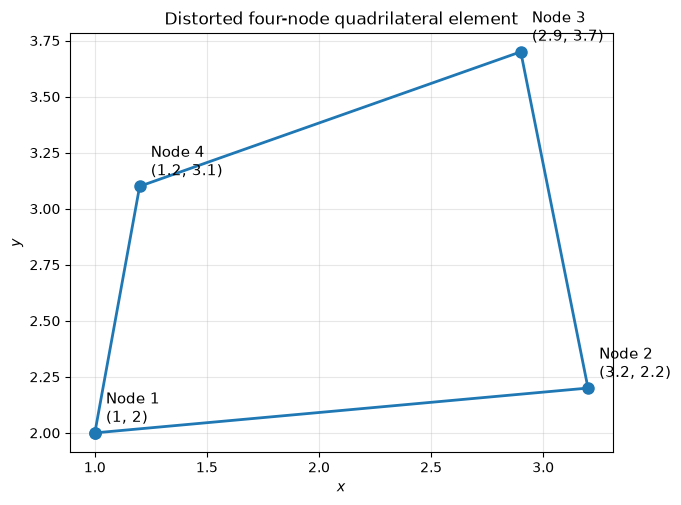

In [1]:
# put your code here
import numpy as np
import matplotlib.pyplot as plt

# Counterclockwise node coordinates
coordinates = np.array([[1.0, 2.0],
                        [3.2, 2.2],
                        [2.9, 3.7],
                        [1.2, 3.1]])

# Repeat node 1 to close the quadrilateral
polygon = np.vstack((coordinates, coordinates[0]))

fig, ax = plt.subplots(figsize=(7, 6))

# Plot element edges and nodes
ax.plot(
    polygon[:, 0],
    polygon[:, 1],
    "o-",
    color="tab:blue",
    linewidth=2,
    markersize=8
)

# Add node labels
for node_id, (x, y) in enumerate(coordinates, start=1):
    ax.annotate(
        f"Node {node_id}\n({x:g}, {y:g})",
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11
    )

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Distorted four-node quadrilateral element")

ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.show()

---
## Q4 interpolation and stiffness integral

On the reference square $-1\leq\xi,\eta\leq1$, the bilinear shape functions are

$$
N_1=\frac14(1-\xi)(1-\eta),\qquad N_2=\frac14(1+\xi)(1-\eta),
$$

$$
N_3=\frac14(1+\xi)(1+\eta),\qquad N_4=\frac14(1-\xi)(1+\eta).
$$

The isoparametric mapping is

$$x(\xi,\eta)=\sum_{i=1}^{4}N_ix_i,\qquad y(\xi,\eta)=\sum_{i=1}^{4}N_iy_i.$$

Because this element is distorted, $\mathbf J$ and $\det(\mathbf J)$ vary over the reference element. The gradient matrix is 

$$
\mathbf B=\begin{bmatrix}N_{1,x}&N_{2,x}&N_{3,x}&N_{4,x}\\N_{1,y}&N_{2,y}&N_{3,y}&N_{4,y}\end{bmatrix}.
$$


- Define the shape functions and their derivatives for further calculations.

In [2]:
def shape_functions_q4(xi, eta):
    return 0.25 * np.array([(1 - xi) * (1 - eta),
                            (1 + xi) * (1 - eta),
                            (1 + xi) * (1 + eta),
                            (1 - xi) * (1 + eta)])


def shape_derivatives_q4(xi, eta):
    # Row i contains [dNi/dxi, dNi/deta].
    return 0.25 * np.array([[-(1 - eta), -(1 - xi)],
                            [ (1 - eta), -(1 + xi)],
                            [ (1 + eta),  (1 + xi)],
                            [-(1 + eta),  (1 - xi)]])

The scalar stiffness matrix is

$$
\mathbf K^{(e)}=\int_{-1}^{1}\int_{-1}^{1}k \mathbf B^T\mathbf B\,\det(\mathbf J)\,d\xi\,d\eta.
$$




## Two-by-two Gaussian quadrature

**The quadrature points are $\xi,\eta=\pm1/\sqrt3$, with unit weights.** At every point,

$$
\mathbf J=\begin{bmatrix}\partial x/\partial\xi&\partial x/\partial\eta\\\partial y/\partial\xi&\partial y/\partial\eta\end{bmatrix}.
$$

Differentiating the isoparametric coordinate mapping gives

$$
\frac{\partial x}{\partial \xi}
=
\sum_{i=1}^{4}
x_i
\frac{\partial N_i}{\partial \xi},
~~\text{and}~~
\frac{\partial x}{\partial \eta}
=
\sum_{i=1}^{4}
x_i
\frac{\partial N_i}{\partial \eta}.
$$

Similarly,

$$
\frac{\partial y}{\partial \xi}
=
\sum_{i=1}^{4}
y_i
\frac{\partial N_i}{\partial \xi},
~~\text{and}~~
\frac{\partial y}{\partial \eta}
=
\sum_{i=1}^{4}
y_i
\frac{\partial N_i}{\partial \eta}.
$$

Therefore, the Jacobian matrix can be written as

$$
\mathbf J
=
\begin{bmatrix}
\displaystyle\sum_{i=1}^{4}
x_i\frac{\partial N_i}{\partial \xi}
&
\displaystyle\sum_{i=1}^{4}
x_i\frac{\partial N_i}{\partial \eta}
\\[12pt]
\displaystyle\sum_{i=1}^{4}
y_i\frac{\partial N_i}{\partial \xi}
&
\displaystyle\sum_{i=1}^{4}
y_i\frac{\partial N_i}{\partial \eta}
\end{bmatrix}.
$$

---
To compute the Jacobian, we will use the nodal coordinates and the derivatives of the natural shape functions. The coordinate matrix is

$$
\mathbf X
=
\begin{bmatrix}
x_1 & y_1 \\
x_2 & y_2 \\
x_3 & y_3 \\
x_4 & y_4
\end{bmatrix}.
$$

Its transpose is

$$
\mathbf X^T
=
\begin{bmatrix}
x_1 & x_2 & x_3 & x_4 \\
y_1 & y_2 & y_3 & y_4
\end{bmatrix}.
$$

The natural-coordinate shape-function derivative matrix is

$$
\mathbf D_N
=
\begin{bmatrix}
N_{1,\xi} & N_{1,\eta} \\
N_{2,\xi} & N_{2,\eta} \\
N_{3,\xi} & N_{3,\eta} \\
N_{4,\xi} & N_{4,\eta}
\end{bmatrix}.
$$

Therefore, the Jacobian matrix is

$$
\mathbf J
=
\mathbf X^T\mathbf D_N 
=
\begin{bmatrix}
x_1 & x_2 & x_3 & x_4 \\
y_1 & y_2 & y_3 & y_4
\end{bmatrix}
\begin{bmatrix}
N_{1,\xi} & N_{1,\eta} \\
N_{2,\xi} & N_{2,\eta} \\
N_{3,\xi} & N_{3,\eta} \\
N_{4,\xi} & N_{4,\eta}
\end{bmatrix}.
$$

- Use `np.legendre.` to find the Gaussian points and weights.

In [3]:
gauss_points, gauss_weights = np.polynomial.legendre.leggauss(2)

print("Gaussian points: ", gauss_points)
print("Gaussian weights: ", gauss_weights)

Gaussian points:  [-0.57735027  0.57735027]
Gaussian weights:  [1. 1.]


- Plot the quadrature points on the element.

Since 

$$x(\xi,\eta)=\sum_{i=1}^{4}N_ix_i,\qquad y(\xi,\eta)=\sum_{i=1}^{4}N_iy_i,$$

the phyical coordinates of any $(\xi, \eta)$ can be obtained using 

$$\begin{bmatrix} x(\xi,\eta) & y(\xi,\eta) \end{bmatrix}= \begin{bmatrix} N_1 & N_2 &  N_3 & N_4 \end{bmatrix} \cdot \begin{bmatrix}
x_1 & y_1 \\
x_2 & y_2 \\
x_3 & y_3 \\
x_4 & y_4
\end{bmatrix}
$$

  

Physical coordiantes of Gaussian points:  [[1.48485058 2.2925856 ]
 [1.5393164  2.97647429]
 [2.69401694 2.45685905]
 [2.58181609 3.27408106]]


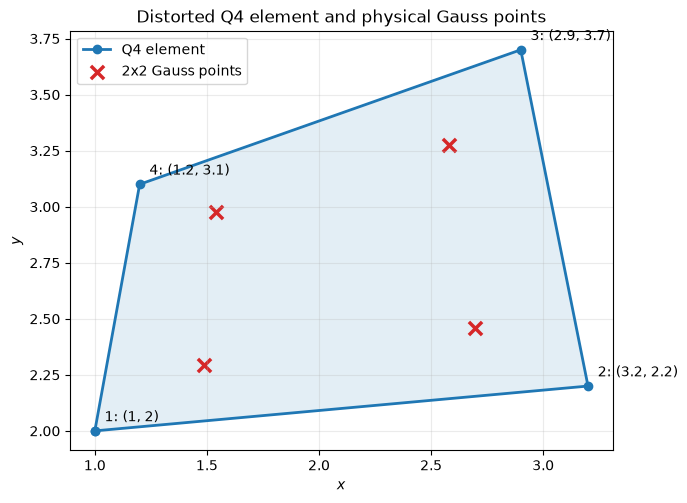

In [4]:
# function to convert local coordinates to global coordinates 
def map_to_physical(xi, eta, xy=coordinates):
    return shape_functions_q4(xi, eta) @ xy
    

GP = np.zeros((4, 2))

q = 0
for xi in gauss_points:
    for eta in gauss_points:
        GP[q, :] = map_to_physical(xi, eta)
        q += 1

print("Physical coordiantes of Gaussian points: ", GP)


# plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.fill(polygon[:, 0], polygon[:, 1], color='tab:blue', alpha=0.12)
ax.plot(polygon[:, 0], polygon[:, 1], 'o-', color='tab:blue', lw=2, label='Q4 element')
ax.scatter(GP[:, 0], GP[:, 1], marker='x', s=90,
           linewidths=2.5, color='tab:red', label='2x2 Gauss points')

for i, (x_i, y_i) in enumerate(coordinates, start=1):
    ax.annotate(f'{i}: ({x_i:g}, {y_i:g})', (x_i, y_i),
                xytext=(7, 7), textcoords='offset points')

ax.set(xlabel='$x$', ylabel='$y$', title='Distorted Q4 element and physical Gauss points')
ax.set_aspect('equal')
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

---
The contribution of one quadrature point is

$$
\mathbf K^{(e)}\;{+}{=}\;k \mathbf B^T\mathbf B\,\det(\mathbf J)w_\xi w_\eta,
$$

where $\mathbf{B}$ is obtained from the physical gradients follow from

$$
[N_{i,x}\;N_{i,y}]=[N_{i,\xi}\;N_{i,\eta}]\mathbf J^{-1}.
$$

Or

$$\mathbf{B} = \big(D_N \mathbf{J}^{-1} \big)^T$$

In [5]:
conductivity = 1.0
Ke = np.zeros((4, 4))

for xi, w_xi in zip(gauss_points, gauss_weights):
    for eta, w_eta in zip(gauss_points, gauss_weights):

        dN_natural = shape_derivatives_q4(xi, eta)

        J = coordinates.T @ dN_natural
        detJ = np.linalg.det(J)

        if detJ <= 0.0:
            raise ValueError(f'Nonpositive Jacobian determinant at ({xi}, {eta})')

        dN_physical = dN_natural @ np.linalg.inv(J)
        B = dN_physical.T
        weight = w_xi * w_eta

        Ke += conductivity * (B.T @ B) * detJ * weight

print('\nElement stiffness matrix Ke =')
print(Ke)


Element stiffness matrix Ke =
[[ 0.68550116  0.0843857  -0.28333599 -0.48655088]
 [ 0.0843857   0.72429488 -0.34218389 -0.46649669]
 [-0.28333599 -0.34218389  0.63394152 -0.00842164]
 [-0.48655088 -0.46649669 -0.00842164  0.96146921]]


For unit conductivity and thickness, the computed matrix is approximately

$$
\mathbf K^{(e)}=\begin{bmatrix}
 0.685501& 0.084386&-0.283336&-0.486551\\
 0.084386& 0.724295&-0.342184&-0.466497\\
-0.283336&-0.342184& 0.633942&-0.008422\\
-0.486551&-0.466497&-0.008422& 0.961469
\end{bmatrix}.
$$

Unlike an affine square or rectangle, the varying Jacobian makes this matrix geometry-dependent.

## Great! Please upload the completed assignment to D2L drop box.